# Music Recommendation System — 03 Model Building

Implicit-feedback ranking: a popularity baseline vs **Item-based CF** vs **SVD matrix factorization**. There is no rating to predict, so we report **Precision@10 / Recall@10** on each user's held-out artists (no RMSE). All numbers are run.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import utils
train=pd.read_csv('data/train.csv'); test=pd.read_csv('data/test.csv'); names=utils.load_items()
M=utils.build_matrix(train,log=True); print('matrix',M.shape)

matrix (1859, 2000)


## 1. Fit models

In [2]:
pop=utils.PopularityBaseline().fit(M); cf=utils.ItemBasedCF().fit(M); svd=utils.SVDRecommender().fit(M,n_components=30)
print('fitted')

fitted


## 2. Ranking @10 (relevant = held-out artists)

In [3]:
rows=[]
for n,m in [('Popularity',pop),('Item-CF',cf),('SVD',svd)]:
    r=utils.precision_recall_at_k(m,M,test,k=10)
    rows.append({'model':n,'precision@k':r['precision@k'],'recall@k':r['recall@k'],'n_users':r['n_users_evaluated']})
rank_df=pd.DataFrame(rows); rank_df

,model,precision@k,recall@k,n_users
0,Popularity,0.0693,0.0841,1859
1,Item-CF,0.1811,0.2454,1859
2,SVD,0.1542,0.1985,1859


## 3. Ranking metrics chart

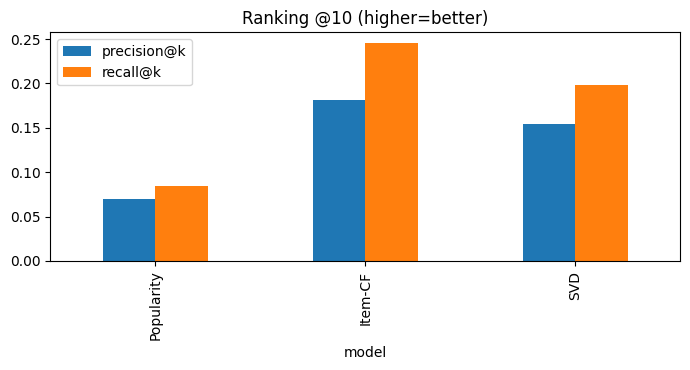

In [4]:
fig,ax=plt.subplots(figsize=(7,3.8))
rank_df.set_index('model')[['precision@k','recall@k']].plot(kind='bar',ax=ax); ax.set_title('Ranking @10 (higher=better)')
plt.tight_layout(); plt.show()

## 4. Example recommendations (Item-CF)

In [5]:
uid=M.index[0]
print('recommendations for user',uid,'\n')
utils.recommend(cf,M,uid,items_lookup=names,n=10)

recommendations for user 2 



,item,name,score
0,72,Depeche Mode,34.238
1,1001,Pet Shop Boys,32.302
2,1014,Erasure,29.102
3,187,a-ha,28.264
4,997,The Human League,26.286
5,998,Orchestral Manoeuvres in the Dark,26.276
6,1892,Eurythmics,26.167
7,993,Simple Minds,25.251
8,159,The Cure,24.807
9,193,Tears for Fears,24.436


## 5. Summary & takeaways

- **Item-based CF wins on implicit feedback** — Precision@10 **0.181**, Recall@10 **0.245**, ahead of SVD (0.154 / 0.199) and well ahead of popularity (0.069 / 0.084).
- **This flips the explicit-feedback result.** In the MovieLens / Book projects SVD won ranking; here, with co-listening counts, neighbourhood similarity between artists is a very strong signal — fans of artist A reliably co-listen to artist B.
- **Popularity is a much stronger baseline here** (R@10 0.084) than in the explicit projects, because a handful of mega-popular artists genuinely are listened to by most users — but personalised CF still nearly triples it.
- **No RMSE for implicit data** — there is no held-out *rating* to predict, only held-out *interactions* to rank. Precision@k / Recall@k are the right (and only) metrics.
- Takeaway: for implicit co-occurrence signals (plays, clicks, purchases), item-item CF is a strong and often superior choice to matrix factorization.